# Elderly Care Risk Prediction
## Exploratory Data Analysis & Model Building
**Dataset:** LASI Wave 1 (Longitudinal Ageing Study in India)  
**Author:** Tushar Sekhri  
**Date:** July 2026

In [3]:
import pyreadstat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful")

All imports successful


In [4]:
#Load the main LASI dataset
df,meta=pyreadstat.read_dta('../data/3_LASI_W1_Individual_v4.dta')

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} individuals")
print(f"Columns: {df.shape[1]:,} variables")

Dataset shape: (73396, 2623)
Rows: 73,396 individuals
Columns: 2,623 variables


In [ ]:
#import sys
#!{sys.executable} -m pip install pyreadstat
#import sys
#!{sys.executable} -m pip install pyreadstat pandas numpy matplotlib seaborn scikit-learn
#import sys
#!{sys.executable} -m pip install shap
#import sys
#!{sys.executable} -m pip install xgboost
#import sys
#!{sys.executable} -m pip install xgboost --upgrade


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3.12 install --upgrade pip


In [6]:
# Selecting required features
features = [
    'dm003', 'dm005',           # gender, age
    'ht001_a',                  # self rated health
    'ht002', 'ht003', 'ht004', 
    'ht005', 'ht006', 'ht007', 
    'ht008', 'ht009', 'ht010',  # diseases
    'ht301',                    # physical impairment
    'ht401', 'ht402', 'ht403', 
    'ht404', 'ht405', 'ht406',  # ADL
    'ht407', 'ht408', 'ht409', 
    'ht410', 'ht411', 'ht412',  # IADL
    'mh101', 'mh104', 'mh105',  # memory
    'living_arrangements',      # lives alone or not
]

ml_df=df[features].copy()


# Create target variable
# In LASI: 1 = has difficulty, 2 = no difficulty
adl_cols = ['ht401','ht402','ht403','ht404','ht405','ht406',
            'ht407','ht408','ht409','ht410','ht411','ht412']


ml_df['needs_care'] = (ml_df[adl_cols] == 1).any(axis=1).astype(int)

print("Target variable distribution:")
print(ml_df['needs_care'].value_counts())
print(f"\n{ml_df['needs_care'].mean()*100:.1f}% of people need care support")


Target variable distribution:
needs_care
0    49174
1    24222
Name: count, dtype: int64

33.0% of people need care support


In [7]:
#checking missing values per column
print("Missing values per columns:",ml_df.isnull().sum().sort_values(ascending=False))



Missing values per columns: mh104                  72681
mh101                  72681
mh105                  72681
ht001_a                  947
ht409                    367
ht301                    325
ht408                    314
ht404                    309
ht412                    309
ht411                    309
ht410                    309
ht407                    309
ht406                    309
ht405                    309
ht403                    309
ht402                    309
ht401                    309
ht003                    196
ht009                    195
ht002                    193
ht010                    188
ht004                    188
ht007                    187
ht006                    186
ht005                    186
ht008                    185
living_arrangements        0
dm003                      0
dm005                      0
needs_care                 0
dtype: int64


In [8]:
# Drop memory columns - 99% missing, unusable
ml_df_clean = ml_df.drop(columns=['mh101', 'mh104', 'mh105'])

# Updated feature list without memory columns
adl_cols = ['ht401','ht402','ht403','ht404','ht405','ht406',
            'ht407','ht408','ht409','ht410','ht411','ht412']

# Drop rows where ADL columns are missing (only 309 rows - very few)
ml_df_clean=ml_df_clean.dropna(subset=adl_cols)

#fill others by mean
ml_df_clean=ml_df_clean.fillna(ml_df_clean.median(numeric_only=True))

print(f"Clean dataset shape{ml_df_clean.shape}")
print(f"dropped rows : {len(ml_df)-len(ml_df_clean):,}")
print(f"missing values now: {ml_df_clean.isnull().sum().sum()}")
print(f"\nTarget distribution:")
print(ml_df_clean['needs_care'].value_counts())

Clean dataset shape(73027, 27)
dropped rows : 369
missing values now: 881

Target distribution:
needs_care
0    48816
1    24211
Name: count, dtype: int64


In [9]:
# Check which columns still have missing values
print("Columns still with missing values:")
print(ml_df_clean.isnull().sum()[ml_df_clean.isnull().sum() > 0])

Columns still with missing values:
ht001_a    726
ht002       18
ht003       21
ht004       13
ht005       11
ht006       11
ht007       12
ht008       10
ht009       19
ht010       13
ht301       27
dtype: int64


In [10]:
# Fill remaining missing values with mode (most frequent value)
# These are categorical columns (1=yes, 2=no) so mode makes more sense than median
cols_with_missing = ['ht001_a', 'ht002', 'ht003', 'ht004', 'ht005', 
                     'ht006', 'ht007', 'ht008', 'ht009', 'ht010', 'ht301']

for col in cols_with_missing:
    mode_val = ml_df_clean[col].mode()[0]
    ml_df_clean[col] = ml_df_clean[col].fillna(mode_val)

print(f"Missing values remaining: {ml_df_clean.isnull().sum().sum()}")
print(f"Dataset shape: {ml_df_clean.shape}")

Missing values remaining: 0
Dataset shape: (73027, 27)


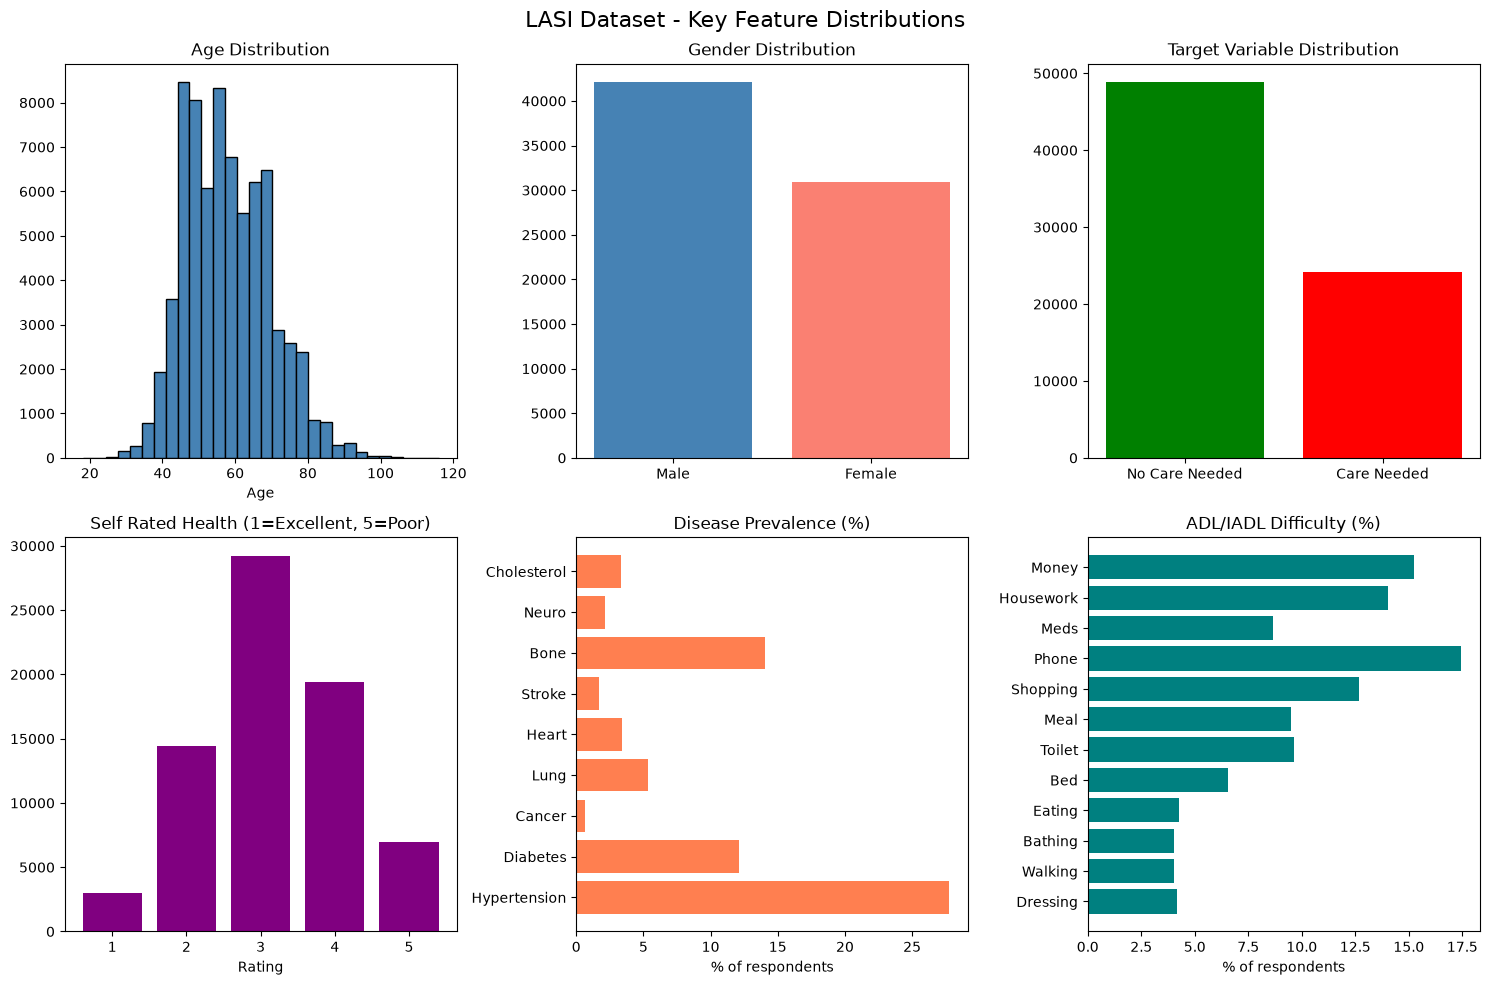

EDA plots saved!


In [11]:
# EDA - Key distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('LASI Dataset - Key Feature Distributions', fontsize=16)

# Age distribution
axes[0,0].hist(ml_df_clean['dm005'], bins=30, color='steelblue', edgecolor='black')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')

# Gender distribution
axes[0,1].bar(['Male', 'Female'], ml_df_clean['dm003'].value_counts().values, color=['steelblue','salmon'])
axes[0,1].set_title('Gender Distribution')

# Target variable
axes[0,2].bar(['No Care Needed', 'Care Needed'], ml_df_clean['needs_care'].value_counts().values, color=['green','red'])
axes[0,2].set_title('Target Variable Distribution')

# Self rated health
srh_counts = ml_df_clean['ht001_a'].value_counts().sort_index()
axes[1,0].bar(srh_counts.index, srh_counts.values, color='purple')
axes[1,0].set_title('Self Rated Health (1=Excellent, 5=Poor)')
axes[1,0].set_xlabel('Rating')

# Disease prevalence
disease_cols = ['ht002','ht003','ht004','ht005','ht006','ht007','ht008','ht009','ht010']
disease_names = ['Hypertension','Diabetes','Cancer','Lung','Heart','Stroke','Bone','Neuro','Cholesterol']
disease_pct = [(ml_df_clean[col] == 1).mean() * 100 for col in disease_cols]
axes[1,1].barh(disease_names, disease_pct, color='coral')
axes[1,1].set_title('Disease Prevalence (%)')
axes[1,1].set_xlabel('% of respondents')

# ADL difficulty
adl_names = ['Dressing','Walking','Bathing','Eating','Bed','Toilet','Meal','Shopping','Phone','Meds','Housework','Money']
adl_pct = [(ml_df_clean[col] == 1).mean() * 100 for col in adl_cols]
axes[1,2].barh(adl_names, adl_pct, color='teal')
axes[1,2].set_title('ADL/IADL Difficulty (%)')
axes[1,2].set_xlabel('% of respondents')

plt.tight_layout()
plt.savefig('../outputs/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved!")

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,roc_auc_score,confusion_matrix
#for training random forest model

X=ml_df_clean.drop(columns=['needs_care'])
y=ml_df_clean['needs_care']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

rf_model=RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf_model.fit(X_train,y_train)

print("Model training complete!")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Model training complete!
Training set: (58421, 26)
Test set: (14606, 26)


Classification Report:
                precision    recall  f1-score   support

No Care Needed       1.00      1.00      1.00      9764
   Care Needed       1.00      1.00      1.00      4842

      accuracy                           1.00     14606
     macro avg       1.00      1.00      1.00     14606
  weighted avg       1.00      1.00      1.00     14606

ROC AUC Score: 1.0000


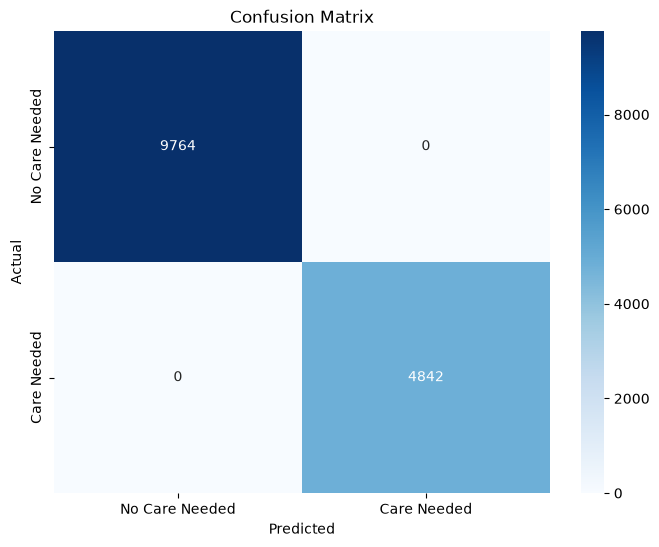

In [13]:
# Evaluate the model
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Care Needed', 'Care Needed']))

# ROC AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Care Needed', 'Care Needed'],
            yticklabels=['No Care Needed', 'Care Needed'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# Remove ADL/IADL columns from features - these define the target so including them is data leakage
adl_cols = ['ht401','ht402','ht403','ht404','ht405','ht406',
            'ht407','ht408','ht409','ht410','ht411','ht412']

X = ml_df_clean.drop(columns=['needs_care'] + adl_cols)
y = ml_df_clean['needs_care']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Retrain
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Model retrained without data leakage!")
print(f"Features used: {X.columns.tolist()}")

Model retrained without data leakage!
Features used: ['dm003', 'dm005', 'ht001_a', 'ht002', 'ht003', 'ht004', 'ht005', 'ht006', 'ht007', 'ht008', 'ht009', 'ht010', 'ht301', 'living_arrangements']


Classification Report:
                precision    recall  f1-score   support

No Care Needed       0.74      0.85      0.79      9764
   Care Needed       0.57      0.39      0.47      4842

      accuracy                           0.70     14606
     macro avg       0.65      0.62      0.63     14606
  weighted avg       0.68      0.70      0.68     14606

ROC AUC Score: 0.6963


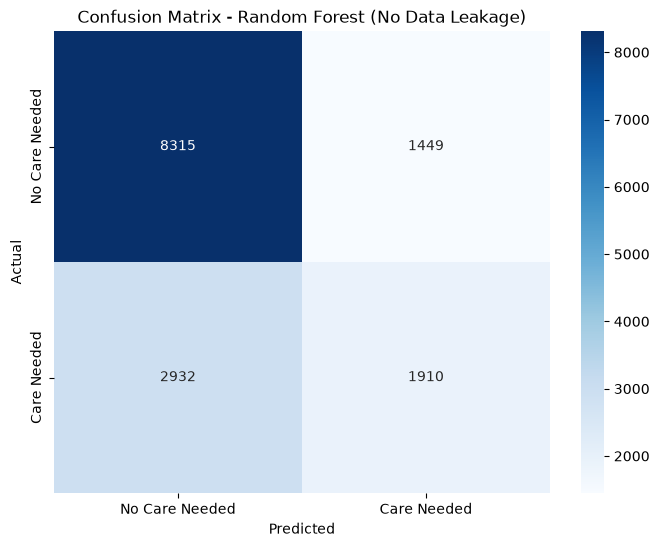

In [15]:
# Evaluate the model
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Care Needed', 'Care Needed']))

# ROC AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Care Needed', 'Care Needed'],
            yticklabels=['No Care Needed', 'Care Needed'])
plt.title('Confusion Matrix - Random Forest (No Data Leakage)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

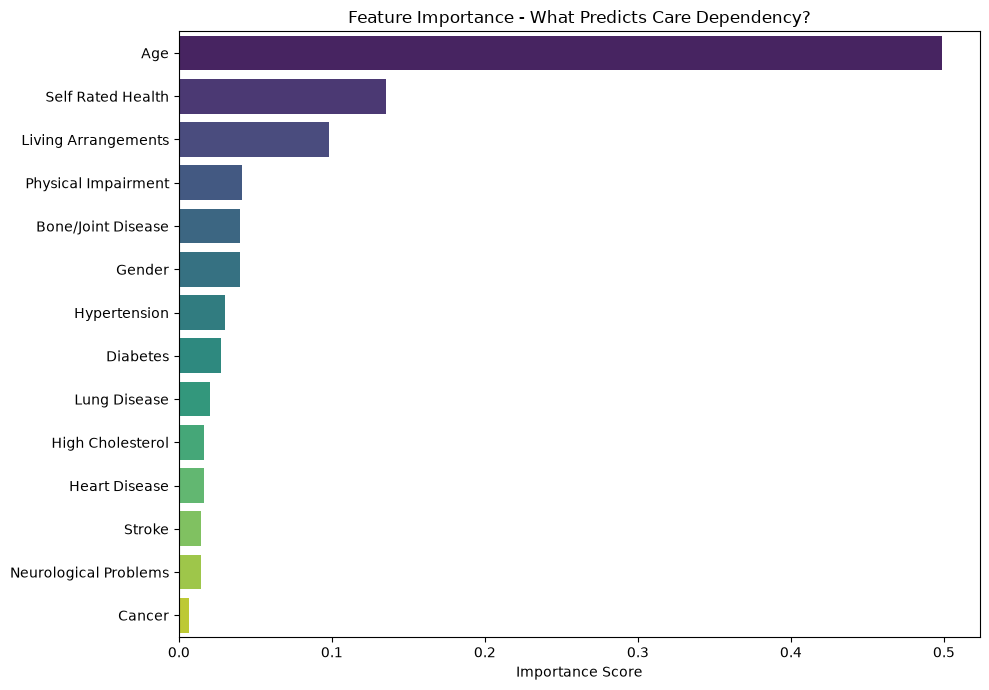

In [16]:
# Feature Importance
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_

# Sort by importance
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# Readable names mapping
name_map = {
    'dm003': 'Gender',
    'dm005': 'Age',
    'ht001_a': 'Self Rated Health',
    'ht002': 'Hypertension',
    'ht003': 'Diabetes',
    'ht004': 'Cancer',
    'ht005': 'Lung Disease',
    'ht006': 'Heart Disease',
    'ht007': 'Stroke',
    'ht008': 'Bone/Joint Disease',
    'ht009': 'Neurological Problems',
    'ht010': 'High Cholesterol',
    'ht301': 'Physical Impairment',
    'living_arrangements': 'Living Arrangements'
}

readable_names = [name_map.get(f, f) for f in sorted_features]

plt.figure(figsize=(10, 7))
sns.barplot(x=sorted_importances, y=readable_names, hue=readable_names, legend=False, palette='viridis')
plt.title('Feature Importance - What Predicts Care Dependency?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


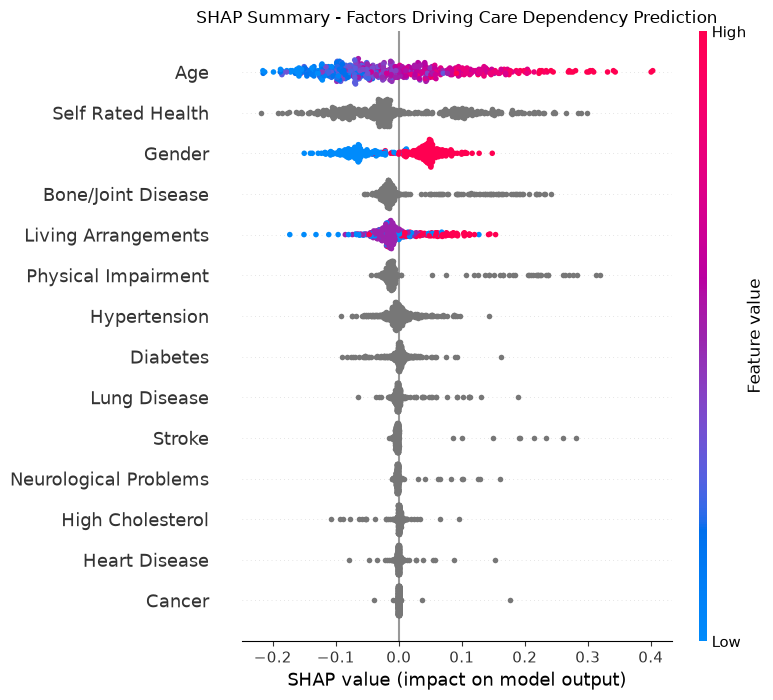

SHAP plot saved!


In [17]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Use a sample of test data -SHAP is slow on full dataset
X_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Rename columns for readability
X_sample_readable = X_sample.rename(columns=name_map)

# Summary plot
shap.summary_plot(
    shap_values[:, :, 1],  # class 1 = Care Needed
    X_sample_readable,
    show=False
)
plt.title('SHAP Summary - Factors Driving Care Dependency Prediction')
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved!")

In [22]:
# from xgboost import XGBClassifier

# xgb_model=XGBClassifier(n_estimators=100,eval_metric='logloss',random_state=42,n_jobs=-1)

# xgb_model.fit(X_train,y_train)

# xgb_pred=xgb_model.predict(X_test)
# xgb_proba_pred=xgb_model.predict_proba(X_test)[:,1]


# print("XGBoost Results:")
# print(classification_report(y_test, y_pred_xgb, target_names=['No Care Needed', 'Care Needed']))
# print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

#logistic regression needs scaled features so scaling it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)


y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr, target_names=['No Care Needed', 'Care Needed']))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

Logistic Regression Results:
                precision    recall  f1-score   support

No Care Needed       0.75      0.89      0.81      9764
   Care Needed       0.65      0.39      0.49      4842

      accuracy                           0.73     14606
     macro avg       0.70      0.64      0.65     14606
  weighted avg       0.71      0.73      0.71     14606

ROC AUC Score: 0.7499


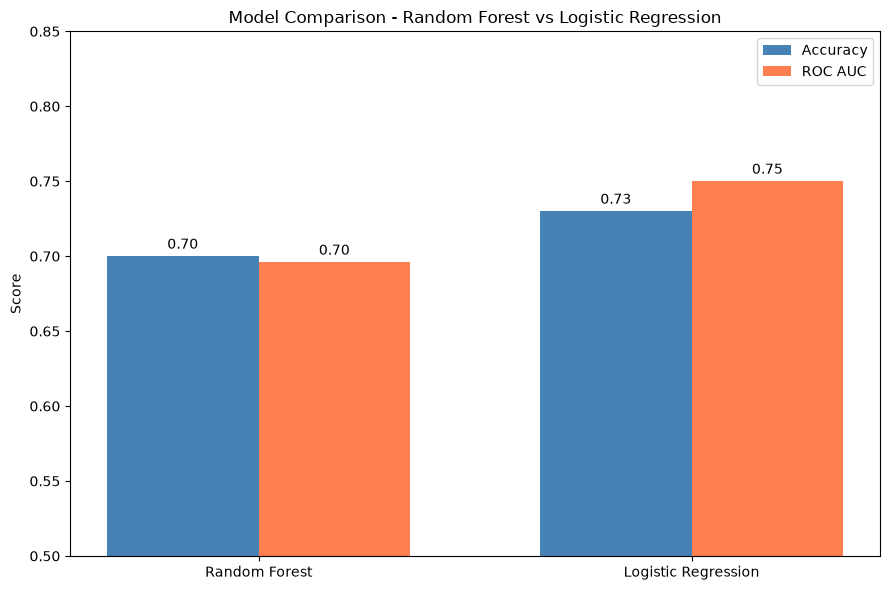

In [25]:
# Model comparison chart
models = ['Random Forest', 'Logistic Regression']
accuracies = [0.70, 0.73]
roc_aucs = [0.696, 0.750]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, roc_aucs, width, label='ROC AUC', color='coral')

ax.set_ylabel('Score')
ax.set_title('Model Comparison - Random Forest vs Logistic Regression')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.5, 0.85)
ax.legend()
ax.bar_label(bars1, padding=3, fmt='%.2f')
ax.bar_label(bars2, padding=3, fmt='%.2f')

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

#logistic regression needs scaled features so scaling it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)


y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr, target_names=['No Care Needed', 'Care Needed']))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

Logistic Regression Results:
                precision    recall  f1-score   support

No Care Needed       0.75      0.89      0.81      9764
   Care Needed       0.65      0.39      0.49      4842

      accuracy                           0.73     14606
     macro avg       0.70      0.64      0.65     14606
  weighted avg       0.71      0.73      0.71     14606

ROC AUC Score: 0.7499
